In [ ]:
# !uv pip install pandas

Using Python 3.12.10 environment at: /mnt/data/elbrus/Final Project/PatentSearchAI/.venv
Resolved 6 packages in 1.20s                                         
⠙ Preparing packages... (0/1)                                                   
⠙ Preparing packages... (0/1)--------------     0 B/15.87 MiB           
⠙ Preparing packages... (0/1)-------------- 16.00 KiB/15.87 MiB         
⠙ Preparing packages... (0/1)-------------- 32.00 KiB/15.87 MiB         
⠙ Preparing packages... (0/1)-------------- 48.00 KiB/15.87 MiB         
⠙ Preparing packages... (0/1)-------------- 64.00 KiB/15.87 MiB         
⠙ Preparing packages... (0/1)-------------- 80.00 KiB/15.87 MiB         
⠙ Preparing packages... (0/1)-------------- 96.00 KiB/15.87 MiB         
⠙ Preparing packages... (0/1)-------------- 112.00 KiB/15.87 MiB        
⠙ Preparing packages... (0/1)-------------- 128.00 KiB/15.87 MiB        
⠙ Preparing packages... (0/1)-------------- 144.00 KiB/15.87 MiB        
⠙ Preparing packages... (0/1)-

In [22]:
!uv pip install -e git+https://github.com/SohierDane/BigQuery_Helper#egg=bq_helper

error: Editable must refer to a local directory, not a Git URL: `git+https://github.com/SohierDane/BigQuery_Helper#egg=bq_helper`


In [2]:
import requests
import pandas as pd
from bs4 import BeautifulSoup

In [ ]:
<heading id="h-0004" class="style-scope patent-text">DETAILED DESCRIPTION</heading>
<div id="p-0041" num="0040" class="description-paragraph style-scope patent-text">In the following description, numerous specific details are set forth, such as particular structures, components, materials, dimensions, processing steps and techniques, in order to provide an understanding of the various embodiments of the present application. However, it will be appreciated by one of ordinary skill in the art that the various embodiments of the present application may be practiced without these specific details. In other instances, well-known structures or processing steps have not been described in detail in order to avoid obscuring the present application.</div>

In [ ]:
# # import requests
# # from bs4 import BeautifulSoup
# # import csv

# # Список патентов (можешь добавить свои)
# patent_urls = [
#     "https://patents.google.com/patent/US12396212B2/en",
#     "https://patents.google.com/patent/US11767896B2/en",
# ]

# # Заголовки для CSV
# output_file = "patents_data.csv"

# # Настройки для запроса
# headers = {"User-Agent": "Mozilla/5.0"}

# # Функция для извлечения данных из одного патента
# def extract_patent_data(url):
#     print(f"Парсинг: {url}")
#     response = requests.get(url, headers=headers)
#     soup = BeautifulSoup(response.text, "html.parser")

#     # Извлекаем заголовок
#     title_tag = soup.find("meta", {"id": "title"})
#     title = title_tag["content"].strip() if title_tag else "N/A"

#     # Извлекаем аннотацию (abstract)
#     abstract_tag = soup.find("div", {"class": "abstract"})
#     abstract = abstract_tag.get_text(strip=True) if abstract_tag else "N/A"

#     # Извлекаем описание (description)
#     description_section = soup.find("section", itemprop="description")
#     description = (
#         description_section.get_text(separator="\n", strip=True)
#         if description_section
#         else "N/A"
#     )

#     return {
#         "url": url,
#         "title": title,
#         "abstract": abstract,
#         "description": description,
#     }

# # Собираем данные по всем патентам
# data = []
# for url in patent_urls:
#     try:
#         patent_data = extract_patent_data(url)
#         data.append(patent_data)
#     except Exception as e:
#         print(f"Ошибка при обработке {url}: {e}")

# # Сохраняем в CSV
# with open(output_file, "w", encoding="utf-8", newline="") as f:
#     writer = csv.DictWriter(f, fieldnames=["url", "title", "abstract", "description"])
#     writer.writeheader()
#     writer.writerows(data)

# print(f"✅ Готово! Данные сохранены в {output_file}")

In [46]:
def get_data(patent_no):
    url = f"https://patents.google.com/patent/{patent_no}/en"
    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, "html.parser")

    # Находим заголовок с текстом DETAILED DESCRIPTION
    heading = soup.find("heading", string=lambda s: s and "DETAILED DESCRIPTION" in s)

    # Собираем все абзацы после него
    description_paragraphs = []
    if heading:
        for sibling in heading.find_all_next("div", class_="description-paragraph"):
            description_paragraphs.append(sibling.get_text(strip=True))

    description_text = "\n".join(description_paragraphs)
    return description_text

In [45]:
patent_list = pd.read_csv("patent_list_2020-2025.csv", header=None)
patent_list = patent_list[0].to_list()

In [ ]:
table = []
for c in range(10):
    patent_row = [patent_list[c], get_data(patent_list[c])]
    table.append(patent_row)

df = pd.DataFrame(
    table,
)

In [ ]:
# import requests
# from bs4 import BeautifulSoup
# import pandas as pd
# import time

# # Настройки поиска
# base_url = "https://patents.google.com/"
# cpc_class = "H10D"
# from_date = "2020-01-01"
# all_patents = []

# headers = {"User-Agent": "Mozilla/5.0"}

# # Берём первые 5 страниц для примера
# for page in range(1, 6):
#     url = f"{base_url}?q=(H10D)&country=US&after=priority:20200101"
#     r = requests.get(url, headers=headers)
#     soup = BeautifulSoup(r.text, "html.parser")

#     # Находим блоки патентов
#     results = soup.find_all("search-result-item")

#     for item in results:
#         title_tag = item.find("span", {"itemprop": "title"})
#         number_tag = item.find("span", {"itemprop": "publicationNumber"})
#         date_tag = item.find("span", {"itemprop": "priorityDate"})
#         link_tag = item.find("a", href=True)

#         all_patents.append(
#             {
#                 "Patent Number": number_tag.text.strip() if number_tag else None,
#                 "Title": title_tag.text.strip() if title_tag else None,
#                 "Priority Date": date_tag.text.strip() if date_tag else None,
#                 "Link": base_url + link_tag["href"] if link_tag else None,
#             }
#         )

#     print(f"Собрано патентов: {len(all_patents)}")
#     time.sleep(1)  # пауза между страницами

# # Создаём DataFrame
# df = pd.DataFrame(all_patents)

Собрано патентов: 0
Собрано патентов: 0
Собрано патентов: 0
Собрано патентов: 0
Собрано патентов: 0


In [ ]:
# df_test = pd.read_csv("H10D-US-2020.csv")
# df_test.head(5)

,id,title,assignee,inventor/author,priority date,filing/creation date,publication date,grant date,result link,representative figure link
0,US-12266540-B2,Method for fabricating layer structure having ...,Asm Ip Holding B.V.,"Eiichiro Shiba, Yoshinori Ota, René Henricus J...",2020-03-12,2023-12-06,2025-04-01,2025-04-01,https://patents.google.com/patent/US12266540B2/en,https://patentimages.storage.googleapis.com/81...
1,US-12075673-B2,Display panel comprising a data line including...,"Wuhan Tianma Micro-Electronics Co., Ltd.","Xingxing Yang, Yangzhao Ma, ZhiQiang Xia",2020-08-27,2023-07-06,2024-08-27,2024-08-27,https://patents.google.com/patent/US12075673B2/en,https://patentimages.storage.googleapis.com/82...
2,US-12200975-B2,Display panel and display apparatus,"Xiamen Tianma Micro-Electronics Co., Ltd.","Jieliang LI, Jiaxian Liu",2020-10-23,2024-01-02,2025-01-14,2025-01-14,https://patents.google.com/patent/US12200975B2/en,https://patentimages.storage.googleapis.com/ce...
3,US-12178053-B2,Memory device and method of forming the same,"Taiwan Semiconductor Manufacturing Company, Ltd.","Chao-I Wu, Yu-Ming Lin",2020-06-18,2024-01-04,2024-12-24,2024-12-24,https://patents.google.com/patent/US12178053B2/en,https://patentimages.storage.googleapis.com/87...
4,US-12136618-B2,Three-dimensional memory device with backside ...,"Yangtze Memory Technologies Co., Ltd.","Kun Zhang, Linchun Wu, Wenxi Zhou, Zhiliang XI...",2020-04-14,2022-07-06,2024-11-05,2024-11-05,https://patents.google.com/patent/US12136618B2/en,https://patentimages.storage.googleapis.com/fc...


In [ ]:
# patent_list_ds = pd.Series([])
# for i in range(2020, 2026):
#     df_temp = df_test = pd.read_csv(f"H10D-US-{i}.csv")
#     id_col = df_temp["id"]
#     patent_list_ds = pd.concat((patent_list_ds, id_col))
# patent_list_ds.head()

0    US-12266540-B2
1    US-12075673-B2
2    US-12200975-B2
3    US-12178053-B2
4    US-12136618-B2
dtype: object

In [ ]:
# patent_list_ds.to_csv("patent_list_2020-2025.csv", index=False, header=False)

In [3]:
df = pd.read_parquet(
    "/mnt/data/elbrus/Final Project/data/us_h10d_patents_000000000000.parquet",
    engine="fastparquet",
)
df.head()

,publication_number,country_code,title,abstract,claims,description,priority_date,assignee,code
0,US-2024404875-A1,US,Air gaps in memory array structures,A memory device includes first transistor over...,What is claimed is: \n \n 1 . A me...,PRIORITY CLAIM AND CROSS-REFERENCE \n This...,20200626,"[Taiwan Semiconductor Manufacturing Co., Ltd.]",H10D62/80
1,US-2024387539-A1,US,Semiconductor devices with edge dielectric fin...,A method for making a semiconductor device inc...,What is claimed is: \n \n 1 . A me...,CROSS-REFERENCE TO RELATED APPLICATIONS \n ...,20210827,"[Taiwan Semiconductor Manufacturing Company, L...",H10D84/0188
2,US-2021215982-A1,US,"Array substrate, display panel, and display de...",An array substrate which can carry a camera in...,What is claimed is: \n \n 1 . An a...,FIELD \n The subject matter herein general...,20200111,"[Hon Hai Precision Industry Co., Ltd.]",H04N23/57
3,US-2022140142-A1,US,Methods of Forming Air Spacers in Semiconducto...,A semiconductor structure includes a source/dr...,What is claimed is: \n \n 1 . A me...,CROSS-REFERENCE TO RELATED APPLICATIONS \n ...,20190916,"[Taiwan Semiconductor Manufacturing Co., Ltd.]",H10D84/834
4,US-2023230533-A1,US,Display device,A display device includes a scan write line co...,What is claimed is: \n \n 1 . A di...,CROSS-REFERENCE TO RELATED APPLICATION \n ...,20220117,"[Samsung Display Co., Ltd.]",H10D86/441


In [15]:
df.shape

(9892, 10)

In [11]:
df["desc_len"] = df["description"].apply(lambda x: len(x.split()))

In [12]:
import matplotlib.pyplot as plt

(array([1.184e+03, 3.449e+03, 2.561e+03, 1.289e+03, 5.360e+02, 2.580e+02,
        1.850e+02, 8.500e+01, 8.700e+01, 6.400e+01, 4.200e+01, 4.100e+01,
        3.300e+01, 1.600e+01, 1.300e+01, 7.000e+00, 5.000e+00, 5.000e+00,
        1.000e+00, 9.000e+00, 8.000e+00, 0.000e+00, 1.000e+00, 3.000e+00,
        2.000e+00, 1.000e+00, 0.000e+00, 1.000e+00, 2.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 1.000e+00]),
 array([   821. ,   4760.7,   8700.4,  12640.1,  16579.8,  20519.5,
         24459.2,  28398.9,  32338.6,  36278.3,  40218. ,  44157.7,
         48097.4,  52037.1,  55976.8,  59916.5,  63856.2,  67795.9,
         71735.6,  75675.3,  79615. ,  83554.7,  87494.4,  91434.1,
         95373.8,  99313.5, 103253.2, 107192.9, 111132.6, 115072.3,
        119012. , 122951.7, 126891.4

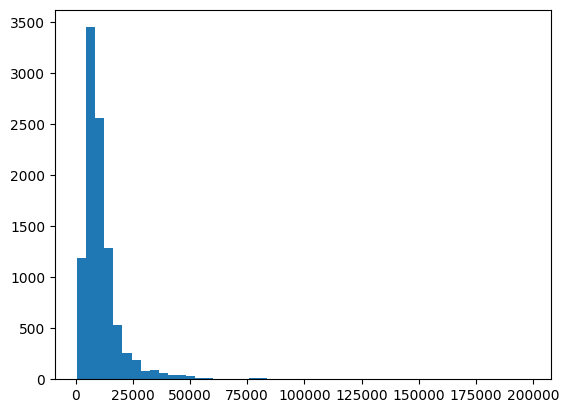

In [13]:
plt.hist(df["desc_len"], bins=50)

In [17]:
import numpy as np

In [18]:
print(df.loc[np.random.randint(0, 9800), "description"])

FIELD OF DISCLOSURE 
     This disclosure generally relates to capacitors, and more specifically, but not exclusively, to compact, space efficient metal oxide metal (MOM) capacitors and methods used to manufacture them. 
     BACKGROUND 
     Modern electronics are becoming more prevalent as smaller electronics enable more applications for the small electronics. One of the basic and widely used components of modern electronics is the capacitor. 
     There is a constant demand to reduce or miniaturize the size and footprint of conventional integrated circuit (IC) devices, packages, etc. The IC packages may include multiple components on a package (like capacitors). It is technically challenging to design and fabricate high density capacitors within a decreasing footprint of modern ICs. 
     Accordingly, there is a need to optimize or improve IC area scaling for evolving and advanced technology nodes. Methods and techniques for increasing design densities within given technology nodes 

In [21]:
df["find"] = df["description"].apply(
    lambda x: (
        True
        if "BRIEF DESCRIPTION OF THE DRAWINGS" and "DETAILED DESCRIPTION" in x
        else False
    )
)
df["find"].sum()

np.int64(8599)

In [22]:
df["find2"] = df["description"].apply(
    lambda x: (True if "DETAILED DESCRIPTION" in x else False)
)
df["find2"].sum()

np.int64(8599)

In [23]:
df["find3"] = df["description"].apply(lambda x: (True if "DESCRIPTION" in x else False))
df["find3"].sum()

np.int64(9871)

In [27]:
len(df[df["find3"] == False].loc[2487, "description"].split())

4272

In [29]:
df[df["find3"] == False]  # .loc[2487, "description"]

,publication_number,country_code,title,abstract,claims,description,priority_date,assignee,code,desc_len,find,find2,find3
994,US-2024363723-A1,US,Multi-threshold voltage integration scheme for...,Methods of manufacturing electronic devices ar...,What is claimed is: \n \n 1 . A me...,TECHNICAL FIELD \n Embodiments of the pres...,20230428,"[Applied Materials, Inc.]",H10D84/0181,13135,False,False,False
1734,US-10658401-B2,US,Carrier release,A technique comprising: providing an assembly ...,The invention claimed is: \n \n 1. A...,CROSS REFERENCE TO RELATED APPLICATIONS \n ...,20160511,[Flexenable Limited],B32B2307/304,3645,False,False,False
2463,US-11450568-B2,US,Silicon carbide integrated circuit,The method of manufacturing an integrated circ...,The invention claimed is: \n \n 1. A...,This application claims priority to UK Patent ...,20170413,[Raytheon Systems Limited],H01L21/046,9024,False,False,False
2487,US-11049968-B2,US,Semiconductor device and method of manufacturi...,A semiconductor memory device comprising a str...,The invention claimed is: \n \n 1. A...,This invention relates to the field of semicon...,20180307,[X-Fab Semiconductor Foundries Gmbh],H10D86/201,4272,False,False,False
3057,US-11222967-B2,US,Heterojunction transistor with vertical structure,The invention concerns a heterojunction field-...,The invention claimed is: \n \n 1. A...,The invention relates to heterojunction transi...,20161129,[Commissariat A L'energie Atomique Atomique Et...,H10D62/8503,6044,False,False,False
3073,US-10686043-B2,US,Method of making semiconductor ferroelectric m...,[Object] To provide a FeFET and a method of it...,The invention claimed is: \n \n 1. A...,TECHNOLOGICAL FIELD \n The present inventi...,20160422,[National Institute Of Advanced Industrial Sci...,H10D64/693,17474,False,False,False
4148,US-2022399442-A1,US,Methods of manufacturing semiconductor devices,A method forms a part of a power semiconductor...,1 - 24 . (canceled) \n \n \n 2...,The present invention relates to a method and ...,20191112,"[Paul Scherrer Institut, Eth Zurich, Eth Trans...",H01L21/3063,4719,False,False,False
4158,US-2024379756-A1,US,Power semiconductor device and manufacturiing ...,A power semiconductor device comprises a semic...,1 . A power semiconductor device comprising a ...,A power semiconductor device is provided. A me...,20211221,[Hitachi Energy Ltd],H10D64/256,6630,False,False,False
4206,US-2025006882-A1,US,Electronic component and method for producing ...,An electronic component has an electronic semi...,1 . An electronic component comprising an elec...,The present invention relates to an electronic...,20211125,[Ams-Osram International Gmbh],H01L25/0753,9825,False,False,False
4411,US-11869810-B2,US,Method for reducing the thickness of solid-sta...,The invention relates to a method for separati...,The invention claimed is: \n \n 1. A...,"The present invention relates, according to cl...",20170420,[Siltectra Gmbh],H10D62/8325,60400,False,False,False


In [30]:
df["abstract+claims"] = df["abstract"] + df["claims"]

In [31]:
df["len_target"] = df["abstract+claims"].apply(lambda x: len(x.split()))

(array([1.540e+02, 8.970e+02, 2.111e+03, 2.824e+03, 2.000e+03, 9.730e+02,
        4.770e+02, 2.150e+02, 9.500e+01, 6.300e+01, 2.900e+01, 2.000e+01,
        1.100e+01, 6.000e+00, 7.000e+00, 4.000e+00, 1.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 1.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00]),
 array([   71.  ,   355.34,   639.68,   924.02,  1208.36,  1492.7 ,
         1777.04,  2061.38,  2345.72,  2630.06,  2914.4 ,  3198.74,
         3483.08,  3767.42,  4051.76,  4336.1 ,  4620.44,  4904.78,
         5189.12,  5473.46,  5757.8 ,  6042.14,  6326.48,  6610.82,
         6895.16,  7179.5 ,  7463.84,  7748.18,  8032.52,  8316.86,
         8601.2 ,  8885.54,  9169.88

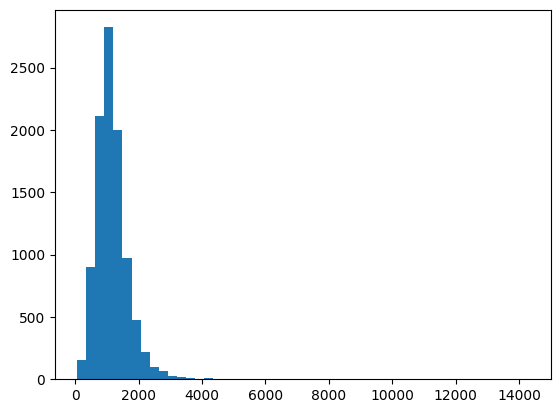

In [32]:
plt.hist(df["len_target"], bins=50)

In [33]:
df["abstract"].isna().sum()

np.int64(0)

In [42]:
df["len_abstract"] = df["abstract"].apply(lambda x: len(x.split()))

In [45]:
df[df["len_abstract"] < 10]

,publication_number,country_code,title,abstract,claims,description,priority_date,assignee,code,desc_len,find,find2,find3,abstract+claims,len_target,len_abstract
2166,US-10725332-B2,US,Display device,The present invention relates to a display dev...,The invention claimed is: \n \n 1. A...,TECHNICAL FIELD \n This application is a N...,20151006,"[Lg Chem, Ltd.]",H10D30/6723,6469,True,True,True,The present invention relates to a display dev...,480,8
